In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

In [3]:
import os
def count_images(folder_path):
    class_counts={}
    total=0
    for class_name in os.listdir(folder_path):
        class_path=os.path.join(folder_path,class_name)
        if os.path.isdir(class_path):
            images=[f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.jpg','.jpeg','.png'))]
            count=len(images)
            class_counts[class_name]=count
            total+=count
    return class_counts,total
# Train
train_counts,train_total=count_images('Dataset_images/Train')
print("Train class wise:",train_counts)
print("Total Train images:",train_total)
# Validation
val_counts,val_total=count_images('Dataset_images/Validation')
print("\nValidation class wise:",val_counts)
print("Total Validation images:",val_total)
# Test
test_counts,test_total=count_images('Dataset_images/Test')
print("\nTest class wise:",test_counts)
print("Total Test images:",test_total)
# Overall Total
overall_total=train_total+val_total+test_total
print("\nOverall Total Images:",overall_total)

Train class wise: {'Fake': 4512, 'Real': 4524}
Total Train images: 9036

Validation class wise: {'Fake': 4056, 'Real': 5183}
Total Validation images: 9239

Test class wise: {'Fake': 108, 'Real': 131}
Total Test images: 239

Overall Total Images: 18514


In [ ]:
img_size=256
batch_size=32
train_datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input,   
    rotation_range=25,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    shear_range=0.2
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
train_data=train_datagen.flow_from_directory(
    'Dataset_images/Train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)
val_data=val_datagen.flow_from_directory(
    'Dataset_images/Validation',
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='binary'
)
test_data=val_datagen.flow_from_directory(
    'Dataset_images/Test',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)
print(train_data.class_indices)

Found 9036 images belonging to 2 classes.
Found 9239 images belonging to 2 classes.
Found 239 images belonging to 2 classes.
{'Fake': 0, 'Real': 1}


In [ ]:
labels=train_data.classes
class_weights=compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:",class_weights)

Class Weights: {0: np.float64(1.0013297872340425), 1: np.float64(0.9986737400530504)}


In [ ]:
base_model=EfficientNetB0(weights='imagenet',include_top=False)
# Freeze initially
for layer in base_model.layers:
    layer.trainable=False
x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dropout(0.5)(x)
output=Dense(1,activation='sigmoid')(x)
model=Model(inputs=base_model.input,outputs=output)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks=[
       EarlyStopping(patience=5,restore_best_weights=True),
    ReduceLROnPlateau(patience=3,factor=0.3)]

In [18]:
history=model.fit(train_data,
    validation_data=val_data,
    epochs=10 ,
    class_weight=class_weights,
    callbacks=callbacks)    

Epoch 1/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 681s 2s/step - accuracy: 0.5333 - loss: 0.7158 - val_accuracy: 0.6454 - val_loss: 0.6430 - learning_rate: 1.0000e-04
Epoch 2/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 1223s 4s/step - accuracy: 0.6475 - loss: 0.6287 - val_accuracy: 0.7569 - val_loss: 0.5656 - learning_rate: 1.0000e-04
Epoch 3/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 794s 3s/step - accuracy: 0.6970 - loss: 0.5881 - val_accuracy: 0.7877 - val_loss: 0.5228 - learning_rate: 1.0000e-04
Epoch 4/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 915s 3s/step - accuracy: 0.7170 - loss: 0.5609 - val_accuracy: 0.7986 - val_loss: 0.4990 - learning_rate: 1.0000e-04
Epoch 5/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 809s 3s/step - accuracy: 0.7326 - loss: 0.5375 - val_accuracy: 0.8089 - val_loss: 0.4789 - learning_rate: 1.0000e-04
Epoch 6/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 676s 2s/step - accuracy: 0.7421 - loss: 0.5297 - val_accuracy: 0.8084 - val_loss: 0.4719 - learning_rate: 1.0000e-04
Epoch 7/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 655s 2s/step - ac

In [19]:
for layer in base_model.layers[-80:]:
    layer.trainable=True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), 
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [20]:
history_fine = model.fit(train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks)

Epoch 1/15
283/283 ━━━━━━━━━━━━━━━━━━━━ 1033s 4s/step - accuracy: 0.7243 - loss: 0.5430 - val_accuracy: 0.8547 - val_loss: 0.3625 - learning_rate: 1.0000e-05
Epoch 2/15
283/283 ━━━━━━━━━━━━━━━━━━━━ 964s 3s/step - accuracy: 0.8290 - loss: 0.4006 - val_accuracy: 0.8350 - val_loss: 0.3497 - learning_rate: 1.0000e-05
Epoch 3/15
283/283 ━━━━━━━━━━━━━━━━━━━━ 935s 3s/step - accuracy: 0.8730 - loss: 0.3113 - val_accuracy: 0.8682 - val_loss: 0.2966 - learning_rate: 1.0000e-05
Epoch 4/15
283/283 ━━━━━━━━━━━━━━━━━━━━ 1087s 4s/step - accuracy: 0.8930 - loss: 0.2631 - val_accuracy: 0.8588 - val_loss: 0.3218 - learning_rate: 1.0000e-05
Epoch 5/15
283/283 ━━━━━━━━━━━━━━━━━━━━ 1054s 4s/step - accuracy: 0.9041 - loss: 0.2338 - val_accuracy: 0.8948 - val_loss: 0.2440 - learning_rate: 1.0000e-05
Epoch 6/15
283/283 ━━━━━━━━━━━━━━━━━━━━ 889s 3s/step - accuracy: 0.9138 - loss: 0.2116 - val_accuracy: 0.8993 - val_loss: 0.2370 - learning_rate: 1.0000e-05
Epoch 7/15
283/283 ━━━━━━━━━━━━━━━━━━━━ 3167s 11s/step 

In [27]:
loss,accuracy=model.evaluate(train_data)
print("Accuracy =",round(accuracy*100,2),"%")

283/283 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - accuracy: 0.9705 - loss: 0.0812
Accuracy = 97.05 %


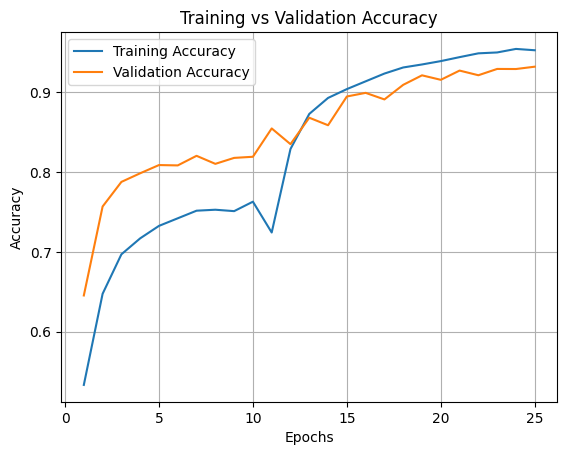

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']
epochs = range(1, len(acc) + 1)
#Accuracy
plt.figure()
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

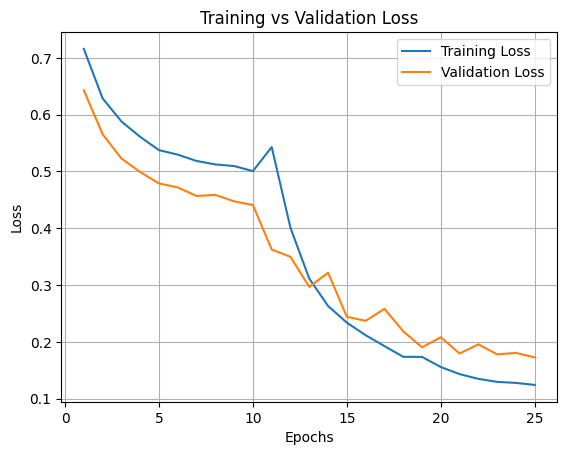

In [ ]:
#loss
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step


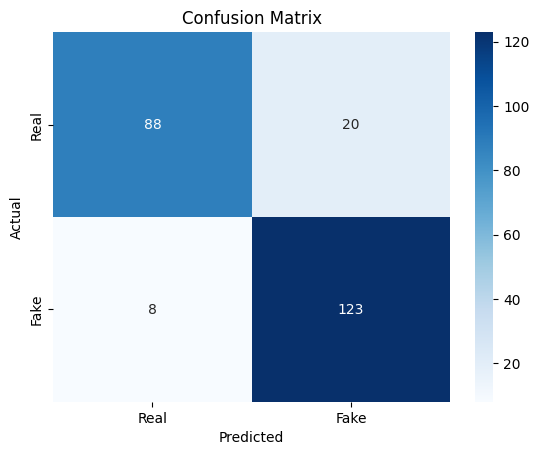

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       108
           1       0.86      0.94      0.90       131

    accuracy                           0.88       239
   macro avg       0.89      0.88      0.88       239
weighted avg       0.89      0.88      0.88       239



In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)
y_true = test_data.classes
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure()
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Real','Fake'],yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step


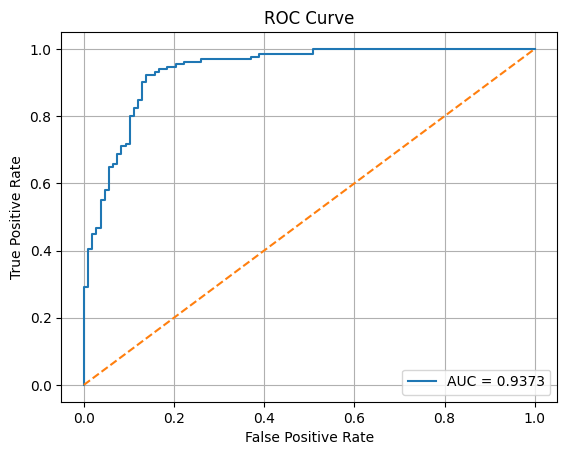

In [29]:
from sklearn.metrics import roc_curve, auc
y_pred_prob = model.predict(test_data)
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

In [30]:
model.save("deepfake_model.keras")

In [1]:
from tensorflow.keras.models import load_model
model = load_model("deepfake_model.keras")

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load model
model = tf.keras.models.load_model("deepfake_model.keras")

# Class labels (IMPORTANT: match your training order)
class_labels = {0: "Real", 1: "Fake"}

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(256, 256))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        print(f"Prediction: Real ({prediction:.4f})")
        return "Real"
    else:
        print(f"Prediction: Fake ({prediction:.4f})")
        return "Fake"

# Example usage
predict_image("Dataset_images/Test/Real/real_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Real (0.9996)


'Real'